# Homework

## Problem 1
Implement serial test and apply to a `samples`

In [6]:
import numpy as np
from scipy.stats import chi2

def serial_test(sample, bins=5):
    """
    Serial test for independence using 2D chi-square.
    sample : 1D array in [0,1]
    bins   : number of subdivisions per axis
    """

    sample = np.asarray(sample)
    
    # обрезаем до чётной длины
    n = len(sample) // 2
    sample = sample[:2*n]
    
    # формируем пары
    pairs = sample.reshape(n, 2)
    
    # 2D гистограмма
    H, _, _ = np.histogram2d(pairs[:,0], pairs[:,1],
                             bins=bins,
                             range=[[0,1],[0,1]])
    
    observed = H.ravel()
    expected = n / (bins**2)
    
    # χ² статистика
    chi_square = np.sum((observed - expected)**2 / expected)
    
    df = bins**2 - 1
    p_value = 1 - chi2.cdf(chi_square, df)
    
    return chi_square, p_value

In [7]:
np.random.seed(0)
sample_good = np.random.rand(10000)

chi, p = serial_test(sample_good, bins=5)
print("Good sample:")
print("Chi-square:", chi)
print("p-value:", p)

Good sample:
Chi-square: 33.44
p-value: 0.09512463791881587


In [8]:
sample_bad = np.sin(np.linspace(0,100,10000)) % 1

chi, p = serial_test(sample_bad, bins=5)
print("\nBad sample:")
print("Chi-square:", chi)
print("p-value:", p)


Bad sample:
Chi-square: 20675.370000000003
p-value: 0.0


## Problem 2*
Implement permutation test and apply to a `samples`

## Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

=== SERIAL TEST ===
Good RNG  -> chi² = 43.8448 , p-value = 0.14513428535422745
Bad RNG   -> chi² = 2491.0096 , p-value = 0.0

=== AUTOCORRELATION (lag=1) ===
Good RNG  -> -0.02279236927655078
Bad RNG   -> 0.15006636368163212


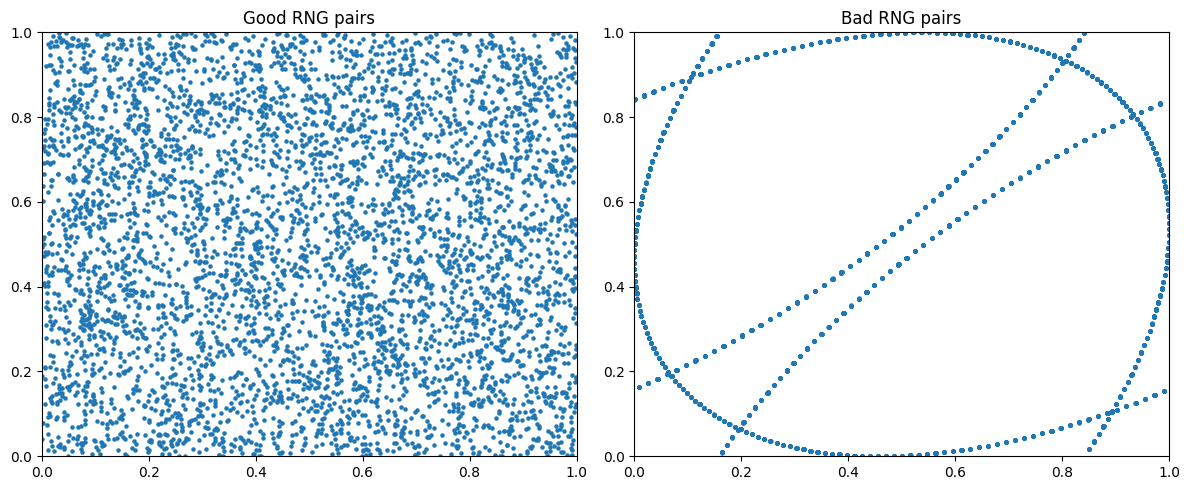

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# -----------------------------
# Генераторы
# -----------------------------
np.random.seed(0)
rng_good = np.random.default_rng(0).random(10000)
rng_bad  = np.sin(np.arange(10000)) % 1


# -----------------------------
# Serial test (2D chi-square)
# -----------------------------
def serial_test(sample, bins=6):
    sample = np.asarray(sample)
    n = len(sample) // 2
    sample = sample[:2*n]
    pairs = sample.reshape(n, 2)

    H, _, _ = np.histogram2d(
        pairs[:, 0], pairs[:, 1],
        bins=bins,
        range=[[0,1],[0,1]]
    )

    observed = H.ravel()
    expected = n / (bins**2)

    chi_square = np.sum((observed - expected)**2 / expected)
    df = bins**2 - 1
    p_value = 1 - chi2.cdf(chi_square, df)

    return chi_square, p_value


# -----------------------------
# Autocorrelation
# -----------------------------
def autocorr(x):
    return np.corrcoef(x[:-1], x[1:])[0,1]


# -----------------------------
# Запуск тестов
# -----------------------------
chi_good, p_good = serial_test(rng_good)
chi_bad,  p_bad  = serial_test(rng_bad)

auto_good = autocorr(rng_good)
auto_bad  = autocorr(rng_bad)


print("=== SERIAL TEST ===")
print("Good RNG  -> chi² =", chi_good, ", p-value =", p_good)
print("Bad RNG   -> chi² =", chi_bad,  ", p-value =", p_bad)

print("\n=== AUTOCORRELATION (lag=1) ===")
print("Good RNG  ->", auto_good)
print("Bad RNG   ->", auto_bad)


# -----------------------------
# Scatter visualization
# -----------------------------
pairs_good = rng_good[:10000].reshape(-1,2)
pairs_bad  = rng_bad[:10000].reshape(-1,2)

fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].scatter(pairs_good[:,0], pairs_good[:,1], s=5)
axs[0].set_title("Good RNG pairs")
axs[0].set_xlim(0,1)
axs[0].set_ylim(0,1)

axs[1].scatter(pairs_bad[:,0], pairs_bad[:,1], s=5)
axs[1].set_title("Bad RNG pairs")
axs[1].set_xlim(0,1)
axs[1].set_ylim(0,1)

plt.tight_layout()
plt.show()

## Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

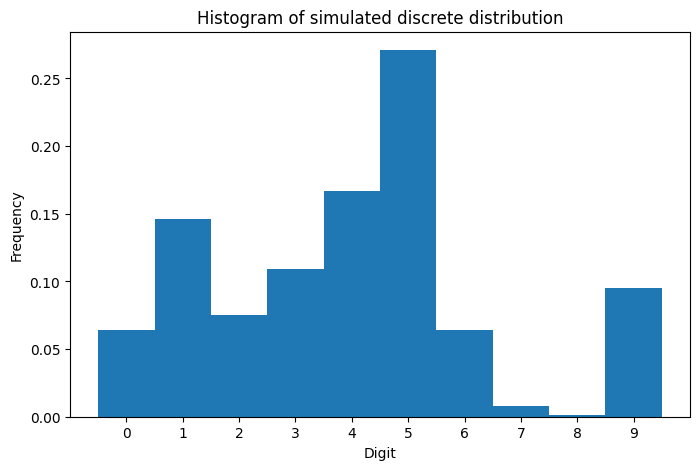

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Исходные веса
# -----------------------------
digits = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31,
                    0.54, 0.111, 0.02, 0.001, 0.2])

# -----------------------------
# Нормировка
# -----------------------------
probs = weights / weights.sum()

# -----------------------------
# Оптимизация: сортировка по убыванию вероятности
# -----------------------------
order = np.argsort(-probs)
probs_sorted = probs[order]
digits_sorted = digits[order]

# Кумулятивная функция распределения
cdf = np.cumsum(probs_sorted)

# -----------------------------
# Генерация выборки (inverse transform)
# -----------------------------
n = 1000
u = np.random.rand(n)

indices = np.searchsorted(cdf, u)
sample = digits_sorted[indices]

# -----------------------------
# Гистограмма
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(sample, bins=np.arange(-0.5, 10.5, 1), density=True)
plt.xticks(digits)
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Histogram of simulated discrete distribution")
plt.show()

## Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

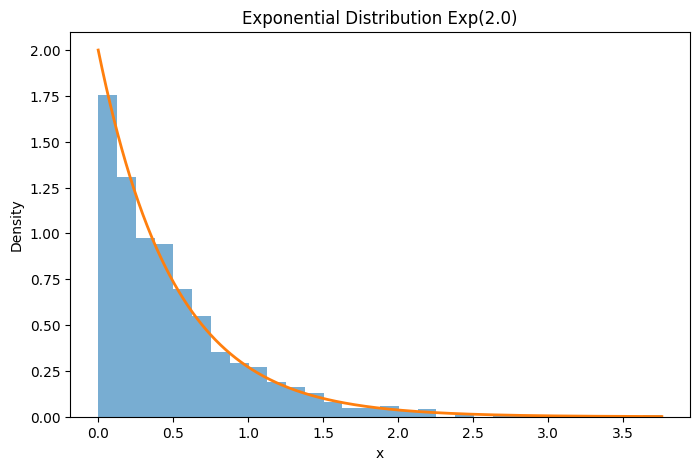

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Параметры
# -----------------------------
np.random.seed(0)
lam = 2.0
n = 1000

# -----------------------------
# Inverse transform sampling
# -----------------------------
U = np.random.rand(n)
sample = -np.log(U) / lam

# -----------------------------
# Гистограмма
# -----------------------------
plt.figure(figsize=(8,5))

# плотность (нормированная гистограмма)
plt.hist(sample, bins=30, density=True, alpha=0.6)

# точная плотность
x = np.linspace(0, sample.max(), 1000)
pdf = lam * np.exp(-lam * x)

plt.plot(x, pdf, linewidth=2)

plt.xlabel("x")
plt.ylabel("Density")
plt.title(f"Exponential Distribution Exp({lam})")
plt.show()

## Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

### Почему метод Accept–Reject работает

Пусть целевая плотность равна $f(x)$, а вспомогательная плотность $g(x)$ такова, что
$$
f(x) \le M g(x)
$$
для некоторой константы $M > 0$.

Алгоритм:
1. Сгенерировать $Y \sim g(x)$.
2. Независимо сгенерировать $U \sim \mathrm{Uniform}(0,1)$.
3. Принять $Y$, если
$$
U \le \frac{f(Y)}{M g(Y)}.
$$

Обоснование:

Совместная плотность $(Y,U)$ равна $g(y)$ на полосе $0 \le U \le 1$.

Вероятность принять значение из малого интервала $[x, x+dx]$ равна
$$
g(x)\,dx \cdot \frac{f(x)}{M g(x)}
= \frac{f(x)}{M}\,dx.
$$

Следовательно, плотность принятых значений пропорциональна $f(x)$.
После нормировки (поскольку принимается лишь доля $1/M$ точек)
получаем точное распределение с плотностью $f(x)$.

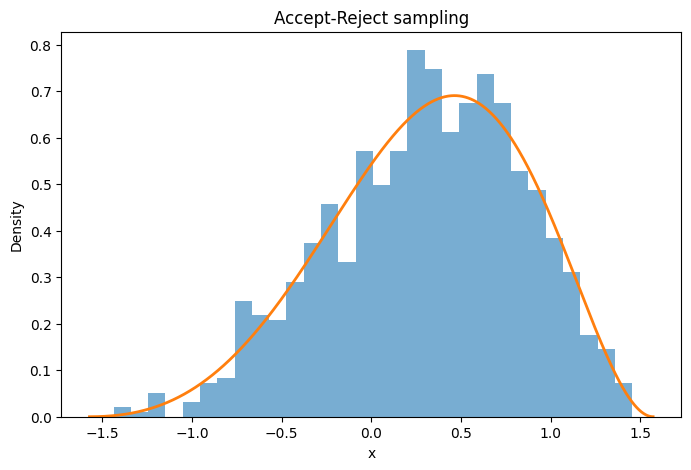

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# -----------------------------
# Параметры
# -----------------------------
n = 1000
a = -np.pi/2
b =  np.pi/2

# целевая плотность (без нормировки)
def f(x):
    return np.exp(x) * np.cos(x)**2

# численно найдём максимум
x_grid = np.linspace(a, b, 10000)
f_max = f(x_grid).max()

# так как g(x) = 1/pi
M = f_max * np.pi

# -----------------------------
# Accept-Reject
# -----------------------------
samples = []

while len(samples) < n:
    Y = np.random.uniform(a, b)
    U = np.random.rand()
    
    if U <= f(Y) / f_max:
        samples.append(Y)

samples = np.array(samples)

# -----------------------------
# Нормировка точной плотности
# -----------------------------
# вычислим интеграл численно
Z = np.trapezoid(f(x_grid), x_grid)

def f_normalized(x):
    return f(x) / Z

# -----------------------------
# График
# -----------------------------
plt.figure(figsize=(8,5))

plt.hist(samples, bins=30, density=True, alpha=0.6)

x_plot = np.linspace(a, b, 1000)
plt.plot(x_plot, f_normalized(x_plot), linewidth=2)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Accept-Reject sampling")
plt.show()

## Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

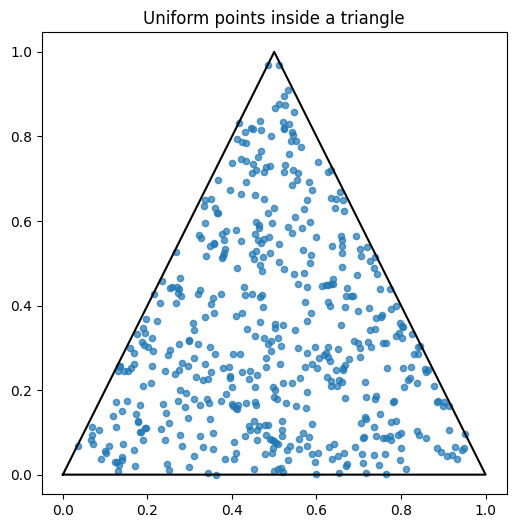

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# -----------------------------
# Вершины треугольника
# -----------------------------
A = np.array([0, 0])
B = np.array([1, 0])
C = np.array([0.5, 1])

n = 500

# -----------------------------
# Генерация точек
# -----------------------------
u = np.random.rand(n)
v = np.random.rand(n)

# геометрический метод
points = (1 - np.sqrt(u))[:, None] * A + \
         (np.sqrt(u) * (1 - v))[:, None] * B + \
         (np.sqrt(u) * v)[:, None] * C

# -----------------------------
# График
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], s=20, alpha=0.7)
plt.plot([A[0], B[0], C[0], A[0]], [A[1], B[1], C[1], A[1]], 'k-', linewidth=1.5)
plt.title("Uniform points inside a triangle")
plt.axis('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

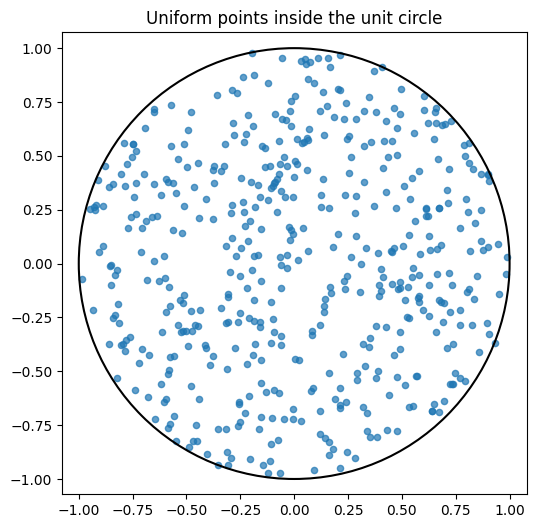

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 500

# -----------------------------
# Полярные координаты
# -----------------------------
theta = np.random.rand(n) * 2 * np.pi
r = np.sqrt(np.random.rand(n))  # sqrt для равномерности по площади

# -----------------------------
# Декартовы координаты
# -----------------------------
x = r * np.cos(theta)
y = r * np.sin(theta)

# -----------------------------
# График
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=20, alpha=0.7)
circle = plt.Circle((0,0), 1, color='k', fill=False, linewidth=1.5)
plt.gca().add_artist(circle)
plt.title("Uniform points inside the unit circle")
plt.axis('equal')
plt.show()

## Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

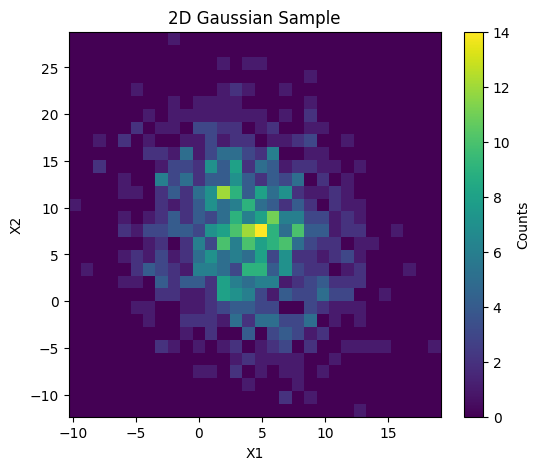

Sample mean: [3.79761628 7.12696678]
True mean:   [4 7]

Sample covariance:
 [[17.43288562 -5.44648588]
 [-5.44648588 40.87845768]]
True covariance:
 [[20 -4]
 [-4 40]]


In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 1000

# -----------------------------
# 1. Box-Muller (polar method)
# -----------------------------
def box_muller_polar(n):
    samples = []
    while len(samples) < n:
        u1 = np.random.uniform(-1,1, size=n)
        u2 = np.random.uniform(-1,1, size=n)
        s = u1**2 + u2**2
        mask = (s > 0) & (s < 1)
        u1 = u1[mask]
        u2 = u2[mask]
        s = s[mask]
        r = np.sqrt(-2*np.log(s)/s)
        samples.extend(np.column_stack((u1*r, u2*r)))
    samples = np.array(samples[:n])
    return samples

Z = box_muller_polar(n)  # shape (n,2), independent N(0,1)

# -----------------------------
# 2. 2D Gaussian
# -----------------------------
mu = np.array([4,7])
Sigma = np.array([[20,-4], [-4,40]])

L = np.linalg.cholesky(Sigma)
X = Z @ L.T + mu  # shape (n,2)

# -----------------------------
# 3. 2D histogram
# -----------------------------
plt.figure(figsize=(6,5))
plt.hist2d(X[:,0], X[:,1], bins=30, cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('2D Gaussian Sample')
plt.show()

# -----------------------------
# 4. Проверка среднего и ковариации
# -----------------------------
sample_mean = X.mean(axis=0)
sample_cov  = np.cov(X.T)

print("Sample mean:", sample_mean)
print("True mean:  ", mu)
print("\nSample covariance:\n", sample_cov)
print("True covariance:\n", Sigma)

## Problem 10*

Implement a method of generating a random partition of an n-element set into subsets. Use it to estimate the expected number of subsets in a random partition of a set of 100 elements.

Hint 1: Ширяев, Вероятность, т1, задача 2 к параграфу 1.

Hint 2: http://djalil.chafai.net/blog/2012/05/03/generating-uniform-random-partitions/